# 模型评估实践：分类问题

本 Notebook 将演示分类任务中的核心评估指标，特别是针对**类别不平衡**场景的处理。我们将使用 **乳腺癌诊断数据集 (Breast Cancer Wisconsin Dataset)**。

## 涉及知识点
- 混淆矩阵
- 常用指标：Accuracy, Precision, Recall, F1-Score
- ROC 曲线与 AUC
- P-R 曲线
- 分层交叉验证 (Stratified CV)

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, precision_recall_curve, classification_report

# 设置绘图风格
sns.set(style="whitegrid")

def config_fonts():
    try:
        # 尝试多种常用中文字体，优先使用挂载的字体
        # SimHei: Windows标准/Docker挂载
        # Heiti TC: Mac标准
        fonts = ['SimHei', 'Heiti TC', 'WenQuanYi Micro Hei', 'DejaVu Sans']
        plt.rcParams['font.sans-serif'] = fonts
        plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
    except Exception as e:
        print(f'字体设置失败: {e}')

config_fonts()

## 1. 数据准备

In [8]:
data = load_breast_cancer()
X = data.data
y = data.target

# 重置标签：1 为恶性 (Malignant/Positive), 0 为良性 (Benign/Negative)
# 原始数据中 0 是 Malignant, 1 是 Benign。我们希望检测恶性，所以反转一下
y = 1 - y
target_names = ['Benign', 'Malignant']

print(f"样本数量: {X.shape[0]}, 特征数量: {X.shape[1]}")
print(f"类别分布: 良性 {sum(y==0)}, 恶性 {sum(y==1)}")

# 分层划分训练集与测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

样本数量: 569, 特征数量: 30
类别分布: 良性 357, 恶性 212


## 2. 模型训练

In [9]:
model = LogisticRegression(max_iter=10000, random_state=42)
model.fit(X_train, y_train)

# 预测类别
y_pred = model.predict(X_test)
# 预测概率 (用于 ROC/AUC)
y_prob = model.predict_proba(X_test)[:, 1]

## 2.5 交叉验证 (Cross Validation)

使用 `StratifiedKFold` 进行交叉验证，更稳健地评估模型性能。

In [10]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# 定义 K 折交叉验证策略
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 执行交叉验证
# 在癌症诊断中，Recall (查全率) 至关重要
scores_recall = cross_val_score(model, X, y, cv=cv, scoring='recall')
scores_acc = cross_val_score(model, X, y, cv=cv, scoring='accuracy')

print(f"Mean Recall (Sensitivity): {scores_recall.mean():.4f} (+/- {scores_recall.std() * 2:.4f})")
print(f"Mean Accuracy: {scores_acc.mean():.4f}")

Mean Recall (Sensitivity): 0.9246 (+/- 0.1077)
Mean Accuracy: 0.9543


## 3. 混淆矩阵与核心指标

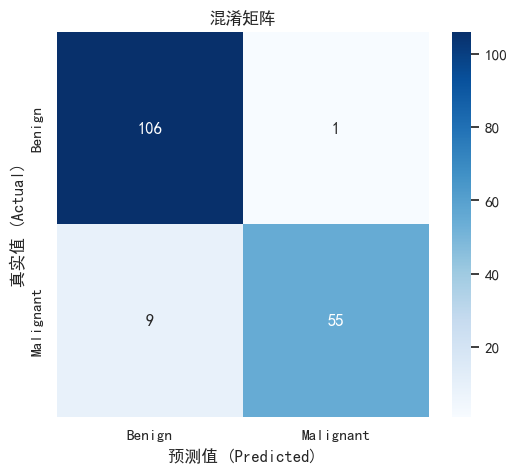


--- 分类报告 ---
              precision    recall  f1-score   support

      Benign       0.92      0.99      0.95       107
   Malignant       0.98      0.86      0.92        64

    accuracy                           0.94       171
   macro avg       0.95      0.93      0.94       171
weighted avg       0.94      0.94      0.94       171

Accuracy:  0.9415
Precision: 0.9821
Recall:    0.8594
F1-Score:  0.9167


In [11]:
# 混淆矩阵
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('预测值 (Predicted)')
plt.ylabel('真实值 (Actual)')
plt.title('混淆矩阵')
plt.show()

# 打印综合分类报告
print("\n--- 分类报告 ---")
print(classification_report(y_test, y_pred, target_names=target_names))

# 单独计算核心指标
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")

## 4. ROC 曲线与 AUC

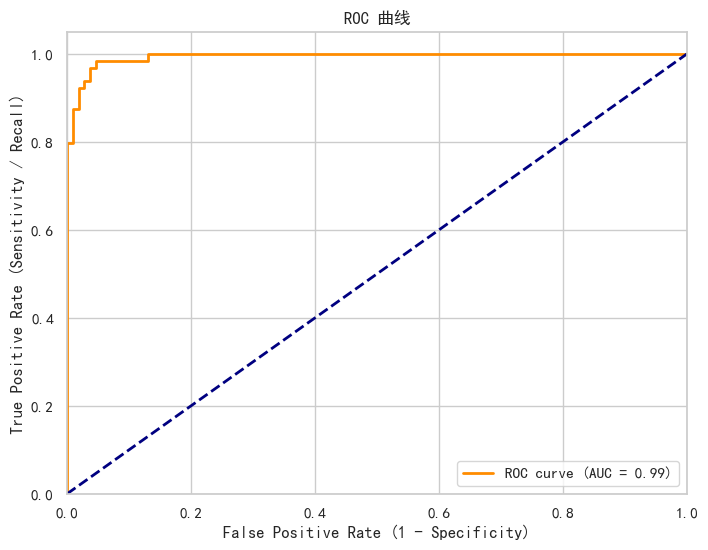

In [12]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title('ROC 曲线')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## 5. P-R 曲线 (Precision-Recall Curve)
在正负样本不平衡时，P-R 曲线更有参考价值。

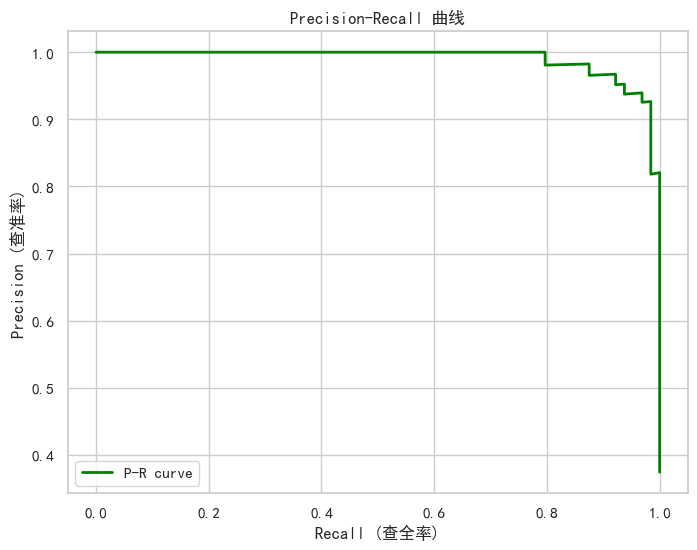

In [13]:
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='green', lw=2, label='P-R curve')
plt.xlabel('Recall (查全率)')
plt.ylabel('Precision (查准率)')
plt.title('Precision-Recall 曲线')
plt.legend(loc="lower left")
plt.grid(True)
plt.show()